In [1]:
# Cell 1 — Imports
from pathlib import Path
import os
import gc

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

2026-05-23 09:08:20.760944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779527300.951285      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779527301.013137      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779527301.512118      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779527301.512159      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779527301.512162      57 computation_placer.cc:177] computation placer alr

In [2]:
# Cell 2 — Configuration
# ==========================================
# CONFIGURATION
# ==========================================
METS_ROOT = Path("/kaggle/input/datasets/ahmedfb/bratsmet24")  # adjust if needed

NUM_CLASSES = 4      # 0: background, 1: necrosis, 2: edema, 3: enhancing tumor
BATCH_SIZE = 8
SHUFFLE_BUFFER = 1500
RANDOM_STATE = 42

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

print("TensorFlow Version:", tf.__version__)
print("Dataset root:", METS_ROOT)
print("Exists:", METS_ROOT.exists())

TensorFlow Version: 2.19.0
Dataset root: /kaggle/input/datasets/ahmedfb/bratsmet24
Exists: True


In [3]:
# Cell 3 — Helper function: get NIfTI from modality folder
def get_nii_from_folder(folder_path: Path):
    """
    Given a folder path, return the ONLY .nii/.nii.gz file inside.
    Returns None if not found or multiple files.
    """
    if not folder_path.exists() or not folder_path.is_dir():
        return None

    nii_files = list(folder_path.glob("*.nii")) + list(folder_path.glob("*.nii.gz"))

    if len(nii_files) != 1:
        return None

    return nii_files[0]

In [4]:
# Cell 4 — Helper function: get segmentation file from case root
def get_seg_from_case_root(case_dir: Path):
    """
    Get segmentation file directly from the case root.
    Looks for *-seg.nii or *-seg.nii.gz
    """
    seg_files = list(case_dir.glob("*-seg.nii")) + list(case_dir.glob("*-seg.nii.gz"))
    seg_files = [f for f in seg_files if f.parent == case_dir]

    if len(seg_files) != 1:
        return None

    return seg_files[0]

In [5]:
# Cell 5 — Main scanner for BraTS dual structure
def scan_modalities_in_case_dual_structure(case_dir: Path):
    """
    Handles both possible structures:
    
    1) Modality stored as a folder containing one .nii/.nii.gz file
    2) Modality stored directly as a .nii/.nii.gz file in case root
    
    Returns:
        case_id, paths_dict
    """
    cid = case_dir.name
    paths = {"t1n": None, "t1c": None, "t2w": None, "t2f": None, "seg": None}

    try:
        items = os.listdir(case_dir)
    except Exception:
        return cid, paths

    for item in items:
        item_path = case_dir / item
        item_lower = item.lower()

        modality = None

        if "t1c" in item_lower or "t1ce" in item_lower:
            modality = "t1c"
        elif "t1n" in item_lower:
            modality = "t1n"
        elif "t2f" in item_lower or "flair" in item_lower:
            modality = "t2f"
        elif "t2w" in item_lower or ("t2" in item_lower and "flair" not in item_lower and "t2f" not in item_lower):
            modality = "t2w"

        if modality:
            if item_path.is_dir():
                nii_path = get_nii_from_folder(item_path)
                if nii_path:
                    paths[modality] = nii_path
            elif item.endswith(".nii") or item.endswith(".nii.gz"):
                paths[modality] = item_path

    seg_path = get_seg_from_case_root(case_dir)
    if seg_path:
        paths["seg"] = seg_path

    return cid, paths

In [6]:
# Cell 6 — Check if case is complete
def is_complete_case(paths_dict):
    return all(paths_dict[k] is not None for k in ["t1n", "t1c", "t2w", "t2f", "seg"])

In [7]:
# Cell 7 — Scan all metastasis cases
all_case_dirs = sorted([p for p in METS_ROOT.iterdir() if p.is_dir()])

records = []

for case_dir in all_case_dirs:
    cid, paths = scan_modalities_in_case_dual_structure(case_dir)

    records.append({
        "case_id": cid,
        "t1n_path": str(paths["t1n"]) if paths["t1n"] else None,
        "t1c_path": str(paths["t1c"]) if paths["t1c"] else None,
        "t2w_path": str(paths["t2w"]) if paths["t2w"] else None,
        "t2f_path": str(paths["t2f"]) if paths["t2f"] else None,
        "seg_path": str(paths["seg"]) if paths["seg"] else None,
        "complete": is_complete_case(paths)
    })

df_cases = pd.DataFrame(records)
df_cases.head()

,case_id,t1n_path,t1c_path,t2w_path,t2f_path,seg_path,complete
0,BraTS-MET-00001-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
1,BraTS-MET-00002-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
2,BraTS-MET-00003-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
3,BraTS-MET-00004-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
4,BraTS-MET-00005-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True


In [8]:
# Cell 8 — Summary of readable cases
print("Total case folders:", len(df_cases))
print("Complete readable cases:", df_cases["complete"].sum())
print("Incomplete cases:", (~df_cases["complete"]).sum())

Total case folders: 328
Complete readable cases: 328
Incomplete cases: 0


In [9]:
# Cell 9 — Keep only complete cases
df_complete = df_cases[df_cases["complete"]].reset_index(drop=True)

print("Usable complete cases:", len(df_complete))
df_complete.head()

Usable complete cases: 328


,case_id,t1n_path,t1c_path,t2w_path,t2f_path,seg_path,complete
0,BraTS-MET-00001-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
1,BraTS-MET-00002-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
2,BraTS-MET-00003-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
3,BraTS-MET-00004-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True
4,BraTS-MET-00005-000,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,/kaggle/input/datasets/ahmedfb/bratsmet24/BraT...,True


In [10]:
# Cell 10 — Segmentation label preparation
def prepare_seg_mask(seg_volume):
    """
    Ensure BraTS labels are in {0,1,2,3}.
    If labels are {0,1,2,4}, remap 4 -> 3.
    """
    seg_volume = seg_volume.astype(np.uint8)
    seg_volume = np.where(seg_volume == 4, 3, seg_volume).astype(np.uint8)
    return seg_volume

In [11]:
# Cell 11 — Inspect one sample case
sample_row = df_complete.iloc[0]

case_id = sample_row["case_id"]
print("Sample case:", case_id)

t1n = nib.load(sample_row["t1n_path"]).get_fdata().astype(np.float32)
t1c = nib.load(sample_row["t1c_path"]).get_fdata().astype(np.float32)
t2w = nib.load(sample_row["t2w_path"]).get_fdata().astype(np.float32)
t2f = nib.load(sample_row["t2f_path"]).get_fdata().astype(np.float32)
seg = np.asanyarray(nib.load(sample_row["seg_path"]).dataobj).astype(np.uint8)
seg_mc = prepare_seg_mask(seg)

print("t1n shape:", t1n.shape)
print("t1c shape:", t1c.shape)
print("t2w shape:", t2w.shape)
print("t2f shape:", t2f.shape)
print("seg shape:", seg_mc.shape)
print("All shapes equal:", t1n.shape == t1c.shape == t2w.shape == t2f.shape == seg_mc.shape)
print("Unique labels in segmentation mask:", np.unique(seg_mc))

Sample case: BraTS-MET-00001-000
t1n shape: (240, 240, 155)
t1c shape: (240, 240, 155)
t2w shape: (240, 240, 155)
t2f shape: (240, 240, 155)
seg shape: (240, 240, 155)
All shapes equal: True
Unique labels in segmentation mask: [0 2 3]


In [12]:
# Cell 12 — Inspect labels across cases
all_labels = set()

for i in range(min(20, len(df_complete))):
    row = df_complete.iloc[i]
    seg_case = np.asanyarray(nib.load(row["seg_path"]).dataobj).astype(np.uint8)
    seg_case = prepare_seg_mask(seg_case)
    labels = np.unique(seg_case)
    all_labels.update(labels.tolist())
    print(f"{row['case_id']} -> {labels}")

print("\nAll labels found across checked cases:", sorted(all_labels))

BraTS-MET-00001-000 -> [0 2 3]
BraTS-MET-00002-000 -> [0 1 2 3]
BraTS-MET-00003-000 -> [0 1 2 3]
BraTS-MET-00004-000 -> [0 1 2 3]
BraTS-MET-00005-000 -> [0 2 3]
BraTS-MET-00006-000 -> [0 1 2 3]
BraTS-MET-00007-000 -> [0 2 3]
BraTS-MET-00008-000 -> [0 1 2 3]
BraTS-MET-00009-000 -> [0 1 2 3]
BraTS-MET-00010-000 -> [0 1 2 3]
BraTS-MET-00011-000 -> [0 1 2 3]
BraTS-MET-00012-000 -> [0 1 2 3]
BraTS-MET-00013-000 -> [0 2 3]
BraTS-MET-00014-000 -> [0 1 2 3]
BraTS-MET-00015-000 -> [0 1 2 3]
BraTS-MET-00016-000 -> [0 2 3]
BraTS-MET-00017-000 -> [0 2 3]
BraTS-MET-00018-000 -> [0 1 2 3]
BraTS-MET-00019-000 -> [0 1 2 3]
BraTS-MET-00020-000 -> [0 1 2 3]

All labels found across checked cases: [0, 1, 2, 3]


In [13]:
# Cell 13 — Robust volume normalization
def normalize_volume_01(vol):
    """
    Robust min-max normalization on a full 3D volume using nonzero voxels only.
    """
    vol = vol.astype(np.float32)
    nz = vol[vol > 0]

    if nz.size == 0:
        return np.zeros_like(vol, dtype=np.float32)

    vmin, vmax = np.percentile(nz, (1, 99))
    vol = np.clip(vol, vmin, vmax)
    vol = (vol - vmin) / (vmax - vmin + 1e-8)
    return vol.astype(np.float32)

In [14]:
# Cell 14 — Full case loader for BraTS Mets
def load_brats_mets_case(case_row):
    """
    Reads one complete BraTS Mets case from manifest row.
    Applies volume-wise normalization to each modality.
    """
    t1n = nib.load(case_row["t1n_path"]).get_fdata().astype(np.float32)
    t1c = nib.load(case_row["t1c_path"]).get_fdata().astype(np.float32)
    t2w = nib.load(case_row["t2w_path"]).get_fdata().astype(np.float32)
    t2f = nib.load(case_row["t2f_path"]).get_fdata().astype(np.float32)

    seg_raw = np.asanyarray(nib.load(case_row["seg_path"]).dataobj).astype(np.uint8)
    seg_mc = prepare_seg_mask(seg_raw)

    assert t1n.shape == t1c.shape == t2w.shape == t2f.shape == seg_mc.shape, \
        f"Shape mismatch in case {case_row['case_id']}"

    t1n = normalize_volume_01(t1n)
    t1c = normalize_volume_01(t1c)
    t2w = normalize_volume_01(t2w)
    t2f = normalize_volume_01(t2f)

    return {
        "case_id": case_row["case_id"],
        "t1n": t1n,
        "t1c": t1c,
        "t2w": t2w,
        "t2f": t2f,
        "seg_raw": seg_raw,
        "seg_mc": seg_mc
    }

In [15]:
# Cell 15 — Test full case loader
case_data = load_brats_mets_case(df_complete.iloc[0])

print("Case ID:", case_data["case_id"])
print("T1n shape:", case_data["t1n"].shape)
print("T1c shape:", case_data["t1c"].shape)
print("T2w shape:", case_data["t2w"].shape)
print("T2f shape:", case_data["t2f"].shape)
print("Seg labels:", np.unique(case_data["seg_mc"]))

Case ID: BraTS-MET-00001-000
T1n shape: (240, 240, 155)
T1c shape: (240, 240, 155)
T2w shape: (240, 240, 155)
T2f shape: (240, 240, 155)
Seg labels: [0 2 3]


In [16]:
# Cell 16 — Extract filtered axial slices
def extract_filtered_slices_from_case(
    case_data,
    drop_empty_brain_slices=True,
    drop_non_tumor_slices=False,
    min_brain_pixels=50
):
    """
    Extract axial 2D slices from one BraTS Mets case with optional filtering.

    Parameters
    ----------
    case_data : dict
        Output of load_brats_mets_case(...)

    drop_empty_brain_slices : bool
        If True, removes slices with too little nonzero MRI content.

    drop_non_tumor_slices : bool
        If True, keeps only slices containing tumor labels > 0.

    min_brain_pixels : int
        Minimum number of nonzero pixels required to consider a slice non-empty.

    Returns
    -------
    X_list, Y_list, meta : lists
    """
    t1n = case_data["t1n"]
    t1c = case_data["t1c"]
    t2w = case_data["t2w"]
    t2f = case_data["t2f"]
    seg = case_data["seg_mc"]
    cid = case_data["case_id"]

    X_list = []
    Y_list = []
    meta = []

    Z = t1n.shape[2]

    for z in range(Z):
        x = np.stack([
            t1n[:, :, z],
            t1c[:, :, z],
            t2w[:, :, z],
            t2f[:, :, z],
        ], axis=-1).astype(np.float32)

        y = seg[:, :, z].astype(np.uint8)

        if drop_empty_brain_slices:
            brain_mask = np.any(x > 0, axis=-1)
            if brain_mask.sum() < min_brain_pixels:
                continue

        if drop_non_tumor_slices:
            if not np.any(y > 0):
                continue

        X_list.append(x)
        Y_list.append(y)
        meta.append({
            "case_id": cid,
            "z": z,
            "has_tumor": bool(np.any(y > 0))
        })

    return X_list, Y_list, meta

In [17]:
# Cell 17 — Build stratification flag based on presence of label 1
def case_contains_label(case_row, label=1):
    """
    Returns True if the segmentation volume of this case contains `label`.
    """
    seg_raw = np.asanyarray(nib.load(case_row["seg_path"]).dataobj).astype(np.uint8)
    seg_mc = prepare_seg_mask(seg_raw)
    return bool(np.any(seg_mc == label))


label1_flags = []

for i in range(len(df_complete)):
    row = df_complete.iloc[i]
    has_label1 = case_contains_label(row, label=1)
    label1_flags.append(has_label1)

df_complete["has_label1"] = label1_flags

print(df_complete["has_label1"].value_counts(dropna=False))
df_complete[["case_id", "has_label1"]].head()

has_label1
True     224
False    104
Name: count, dtype: int64


,case_id,has_label1
0,BraTS-MET-00001-000,False
1,BraTS-MET-00002-000,True
2,BraTS-MET-00003-000,True
3,BraTS-MET-00004-000,True
4,BraTS-MET-00005-000,False


In [18]:
# Cell 18 — Optional label distribution summary
print("Total complete cases:", len(df_complete))
print("Cases WITH label 1:", int(df_complete["has_label1"].sum()))
print("Cases WITHOUT label 1:", int((~df_complete["has_label1"]).sum()))

print("\nProportion with label 1:")
print(df_complete["has_label1"].value_counts(normalize=True))

Total complete cases: 328
Cases WITH label 1: 224
Cases WITHOUT label 1: 104

Proportion with label 1:
has_label1
True     0.682927
False    0.317073
Name: proportion, dtype: float64


In [19]:
# Cell 19 — Stratified train / val / test split at case level
# First split: train vs temp (val + test), stratified by has_label1
train_df, temp_df = train_test_split(
    df_complete,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=df_complete["has_label1"]
)

# Second split: val vs test, stratified again inside temp
relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=temp_df["has_label1"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [20]:
# Cell 20 — Verify no overlap and stratification quality
train_ids = set(train_df["case_id"])
val_ids   = set(val_df["case_id"])
test_ids  = set(test_df["case_id"])

assert len(train_ids & val_ids)  == 0, "Train/Val overlap!"
assert len(train_ids & test_ids) == 0, "Train/Test overlap!"
assert len(val_ids & test_ids)   == 0, "Val/Test overlap!"

print(f"Training cases:   {len(train_df)}")
print(f"Validation cases: {len(val_df)}")
print(f"Test cases:       {len(test_df)}")
print(f"Total:            {len(train_df) + len(val_df) + len(test_df)}")
print("\nNo overlap: ✓")

print("\nLabel-1 stratification check:")
print("Train has_label1:")
print(train_df["has_label1"].value_counts(normalize=True))
print("\nVal has_label1:")
print(val_df["has_label1"].value_counts(normalize=True))
print("\nTest has_label1:")
print(test_df["has_label1"].value_counts(normalize=True))

Training cases:   229
Validation cases: 49
Test cases:       50
Total:            328

No overlap: ✓

Label-1 stratification check:
Train has_label1:
has_label1
True     0.681223
False    0.318777
Name: proportion, dtype: float64

Val has_label1:
has_label1
True     0.693878
False    0.306122
Name: proportion, dtype: float64

Test has_label1:
has_label1
True     0.68
False    0.32
Name: proportion, dtype: float64


In [21]:
# Cell 21 — Slice generator
def brats_mets_slice_generator(
    cases_df,
    shuffle_cases=True,
    drop_empty_brain=True,
    min_brain_pixels=50
):
    """
    Yields (x_slice, y_slice) one slice at a time.
    Only one case is kept in memory at any moment.
    """
    indices = np.arange(len(cases_df))

    if shuffle_cases:
        np.random.shuffle(indices)

    for i in indices:
        case_row = cases_df.iloc[int(i)]

        try:
            case_data = load_brats_mets_case(case_row)
        except Exception as e:
            print(f"⚠ Skipping {case_row['case_id']}: {e}")
            continue

        X_list, Y_list, _ = extract_filtered_slices_from_case(
            case_data,
            drop_empty_brain_slices=drop_empty_brain,
            drop_non_tumor_slices=False,
            min_brain_pixels=min_brain_pixels,
        )

        del case_data
        gc.collect()

        order = np.arange(len(X_list))
        if shuffle_cases:
            np.random.shuffle(order)

        for j in order:
            yield X_list[j], Y_list[j]

        del X_list, Y_list

In [22]:
# Cell 22 — tf.data dataset builder
def make_brats_mets_dataset(
    cases_df,
    batch_size=BATCH_SIZE,
    is_training=True,
    buffer_size=SHUFFLE_BUFFER
):
    sample_shape = nib.load(cases_df.iloc[0]["t1n_path"]).shape
    H, W = sample_shape[0], sample_shape[1]

    def gen():
        return brats_mets_slice_generator(
            cases_df,
            shuffle_cases=is_training,
        )

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(H, W),    dtype=tf.uint8),
        ),
    )

    if is_training:
        ds = ds.shuffle(buffer_size=buffer_size)

    ds = ds.map(
        lambda x, y: (
            x,
            tf.one_hot(tf.cast(y, tf.int32), depth=NUM_CLASSES)
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [23]:
# Cell 23 — Build datasets
train_ds = make_brats_mets_dataset(train_df, batch_size=BATCH_SIZE, is_training=True)
val_ds   = make_brats_mets_dataset(val_df,   batch_size=BATCH_SIZE, is_training=False)
test_ds  = make_brats_mets_dataset(test_df,  batch_size=BATCH_SIZE, is_training=False)

print("Train dataset:", train_ds)
print("Val   dataset:", val_ds)
print("Test  dataset:", test_ds)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None))>
Val   dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None))>
Test  dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None))>


I0000 00:00:1779527456.411049      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
# # Cell 24 — Estimate steps per epoch
# AVG_VALID_SLICES_PER_CASE = 120   # conservative estimate, adjust after inspection

# est_train_slices = len(train_df) * AVG_VALID_SLICES_PER_CASE
# est_val_slices   = len(val_df)   * AVG_VALID_SLICES_PER_CASE
# est_test_slices  = len(test_df)  * AVG_VALID_SLICES_PER_CASE

# train_steps = est_train_slices // BATCH_SIZE
# val_steps   = est_val_slices   // BATCH_SIZE
# test_steps  = est_test_slices  // BATCH_SIZE

# print(f"Train cases: {len(train_df)}")
# print(f"Val   cases: {len(val_df)}")
# print(f"Test  cases: {len(test_df)}")

# print(f"\nEstimated train steps/epoch: {train_steps}")
# print(f"Estimated val   steps/epoch: {val_steps}")
# print(f"Estimated test  steps:       {test_steps}")

In [27]:
# # Cell 25 — Optional: compute exact slice counts after filtering
# def count_filtered_slices(cases_df, drop_empty_brain=True, min_brain_pixels=50):
#     total_slices = 0
#     total_tumor_slices = 0

#     for i in range(len(cases_df)):
#         row = cases_df.iloc[i]
#         try:
#             case_data = load_brats_mets_case(row)
#             _, Y_list, meta = extract_filtered_slices_from_case(
#                 case_data,
#                 drop_empty_brain_slices=drop_empty_brain,
#                 drop_non_tumor_slices=False,
#                 min_brain_pixels=min_brain_pixels
#             )
#             total_slices += len(Y_list)
#             total_tumor_slices += sum(m["has_tumor"] for m in meta)
#         except Exception as e:
#             print(f"⚠ Skipping {row['case_id']} during counting: {e}")

#     return total_slices, total_tumor_slices


# train_slice_count, train_tumor_slice_count = count_filtered_slices(train_df)
# val_slice_count, val_tumor_slice_count     = count_filtered_slices(val_df)
# test_slice_count, test_tumor_slice_count   = count_filtered_slices(test_df)

# print("Exact filtered slice counts:")
# print(f"Train: total={train_slice_count}, tumor={train_tumor_slice_count}")
# print(f"Val:   total={val_slice_count}, tumor={val_tumor_slice_count}")
# print(f"Test:  total={test_slice_count}, tumor={test_tumor_slice_count}")

# print("\nExact steps:")
# print("Train steps:", train_slice_count // BATCH_SIZE)
# print("Val steps:  ", val_slice_count // BATCH_SIZE)
# print("Test steps: ", test_slice_count // BATCH_SIZE)

KeyboardInterrupt: 

In [24]:
# Cell 26 — Loss functions: Dice + Weighted CE
import tensorflow.keras.backend as K

# IMPORTANT:
# Replace these pixel counts with the actual counts from your metastasis dataset
# if/when you compute them. These are placeholders.
pixel_counts = {
    0: 2031879548,  # background
    1: 584248,      # necrosis
    2: 10194004,     # edema
    3: 1854200,      # enhancing
}

def compute_class_weights(counts, mode="sqrt_inv"):
    """
    Compute class weights from pixel counts.
    
    Modes:
      'inv'      — raw inverse frequency
      'sqrt_inv' — sqrt of inverse frequency
      'log_inv'  — log of inverse frequency
    """
    total = sum(counts.values())
    n = len(counts)

    raw_weights = {c: total / (n * count) for c, count in counts.items()}

    if mode == "inv":
        weights = raw_weights
    elif mode == "sqrt_inv":
        weights = {c: np.sqrt(w) for c, w in raw_weights.items()}
    elif mode == "log_inv":
        weights = {c: np.log(1 + w) for c, w in raw_weights.items()}
    else:
        raise ValueError(f"Unknown mode: {mode}")

    min_w = min(weights.values())
    weights = {c: w / min_w for c, w in weights.items()}

    return weights


class_weights = compute_class_weights(pixel_counts, mode="sqrt_inv")
print("Class weights (sqrt inverse frequency):")
for c, w in class_weights.items():
    print(f"  Class {c}: {w:.4f}")

CLASS_WEIGHT_TENSOR = tf.constant(
    [class_weights[c] for c in range(NUM_CLASSES)],
    dtype=tf.float32
)

Class weights (sqrt inverse frequency):
  Class 0: 1.0000
  Class 1: 58.9726
  Class 2: 14.1181
  Class 3: 33.1033


In [25]:
# Cell 27 — Dice loss and weighted CE
def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Soft Dice loss averaged over all classes including background.
    y_true: (B, H, W, C) one-hot
    y_pred: (B, H, W, C) softmax
    """
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, NUM_CLASSES])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)

    mean_dice = tf.reduce_mean(dice_per_class, axis=-1)
    return 1.0 - tf.reduce_mean(mean_dice)


def weighted_ce(y_true, y_pred):
    """
    Weighted categorical cross-entropy.
    """
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    ce = -y_true * tf.math.log(y_pred)
    weighted = ce * CLASS_WEIGHT_TENSOR
    return tf.reduce_mean(tf.reduce_sum(weighted, axis=-1))


DICE_WEIGHT = 0.5
CE_WEIGHT   = 0.5

def combined_loss(y_true, y_pred):
    """
    Combined Dice loss + Weighted cross-entropy.
    """
    return DICE_WEIGHT * dice_loss(y_true, y_pred) + CE_WEIGHT * weighted_ce(y_true, y_pred)

print("Loss function ready: combined_loss (Dice + Weighted CE)")

Loss function ready: combined_loss (Dice + Weighted CE)


In [26]:
# Cell 28 — Dice metrics
def dice_coef(y_true, y_pred, smooth=1e-6):
    """Mean Dice over tumor classes only (1, 2, 3). Skips background."""
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, NUM_CLASSES])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)

    tumor_dice = dice_per_class[:, 1:]
    return tf.reduce_mean(tumor_dice)


def _dice_single(y_true, y_pred, class_idx, smooth=1e-6):
    y_t = y_true[..., class_idx]
    y_p = y_pred[..., class_idx]

    y_t_f = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p_f = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    inter = tf.reduce_sum(y_t_f * y_p_f, axis=1)
    union = tf.reduce_sum(y_t_f, axis=1) + tf.reduce_sum(y_p_f, axis=1)

    return tf.reduce_mean((2.0 * inter + smooth) / (union + smooth))


def dice_ncr(y_true, y_pred):
    """Dice — class 1"""
    return _dice_single(y_true, y_pred, 1)

def dice_ed(y_true, y_pred):
    """Dice — class 2"""
    return _dice_single(y_true, y_pred, 2)

def dice_et(y_true, y_pred):
    """Dice — class 3"""
    return _dice_single(y_true, y_pred, 3)

print("Metrics ready: dice_coef, dice_ncr, dice_ed, dice_et")

Metrics ready: dice_coef, dice_ncr, dice_ed, dice_et


In [39]:
# Cell 29 — Sanity check one batch
for xb, yb in train_ds.take(1):
    print("X batch shape:", xb.shape)
    print("Y batch shape:", yb.shape)
    print("X dtype:", xb.dtype)
    print("Y dtype:", yb.dtype)
    print("Per-pixel one-hot depth:", yb.shape[-1])
    break

X batch shape: (8, 240, 240, 4)
Y batch shape: (8, 240, 240, 4)
X dtype: <dtype: 'float32'>
Y dtype: <dtype: 'float32'>
Per-pixel one-hot depth: 4


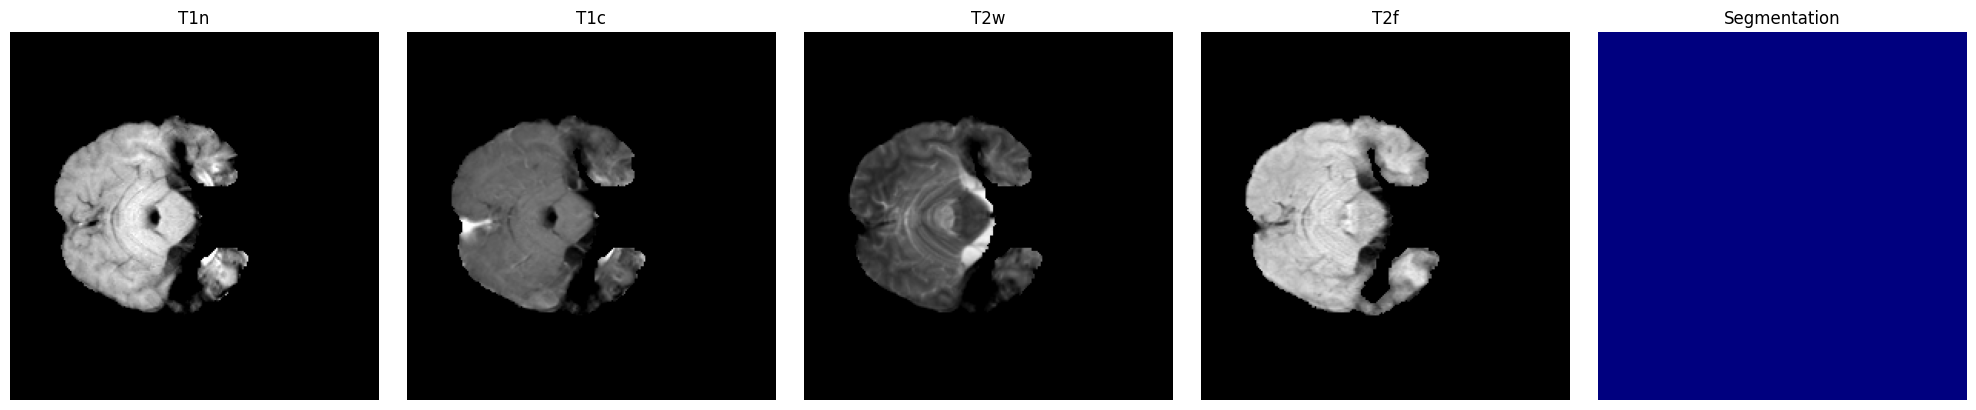

In [28]:
# Cell 30 — Optional visualization of one sample slice
for xb, yb in train_ds.take(1):
    x0 = xb[0].numpy()
    y0 = tf.argmax(yb[0], axis=-1).numpy()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(x0[..., 0], cmap="gray")
    axes[0].set_title("T1n")
    axes[0].axis("off")

    axes[1].imshow(x0[..., 1], cmap="gray")
    axes[1].set_title("T1c")
    axes[1].axis("off")

    axes[2].imshow(x0[..., 2], cmap="gray")
    axes[2].set_title("T2w")
    axes[2].axis("off")

    axes[3].imshow(x0[..., 3], cmap="gray")
    axes[3].set_title("T2f")
    axes[3].axis("off")

    axes[4].imshow(y0, cmap="jet", vmin=0, vmax=3)
    axes[4].set_title("Segmentation")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()
    break

In [29]:
# Cell 31 — Sample slices with overlay for Mets (training set only)

def plot_sample_slices_with_overlay_mets(
    cases_df,
    num_cases=3,
    slices_per_case=2,
    class_colors=None,
    title="Sample Training Slices - BraTS Mets"
):
    """
    Loads a few random BraTS Mets cases, selects tumor-containing slices,
    and visualizes the 4 modalities, mask, and overlay.

    Parameters
    ----------
    cases_df : pd.DataFrame
        Usually train_df for training-set-only visualization.

    num_cases : int
        Number of random cases to sample.

    slices_per_case : int
        Number of tumor slices to visualize per case.

    class_colors : dict or None
        Color map for labels {0,1,2,3}.

    title : str
        Figure title.
    """
    if class_colors is None:
        class_colors = {
            0: [0, 0, 0],       # background
            1: [255, 0, 0],     # label 1
            2: [0, 255, 0],     # edema
            3: [0, 0, 255],     # enhancing
        }

    modality_names = ["T1n", "T1c", "T2w", "T2f"]

    num_cases = min(num_cases, len(cases_df))
    chosen_cases = cases_df.sample(n=num_cases, random_state=42)

    all_rows = []   # will store tuples: (case_id, z, x_slice, y_slice)

    for _, row in chosen_cases.iterrows():
        try:
            case_data = load_brats_mets_case(row)

            X_list, Y_list, meta = extract_filtered_slices_from_case(
                case_data,
                drop_empty_brain_slices=True,
                drop_non_tumor_slices=True,   # only tumor slices for visualization
                min_brain_pixels=50
            )

            del case_data
            gc.collect()

            if len(X_list) == 0:
                print(f"No tumor slices found for case: {row['case_id']}")
                continue

            indices = np.random.choice(
                len(X_list),
                min(slices_per_case, len(X_list)),
                replace=False
            )

            for idx in indices:
                all_rows.append((
                    meta[idx]["case_id"],
                    meta[idx]["z"],
                    X_list[idx],
                    Y_list[idx]
                ))

            del X_list, Y_list, meta

        except Exception as e:
            print(f"⚠ Skipping {row['case_id']} during visualization: {e}")

    if len(all_rows) == 0:
        print("No tumor slices found in selected training cases.")
        return

    fig, axes = plt.subplots(len(all_rows), 6, figsize=(24, 4 * len(all_rows)))

    if len(all_rows) == 1:
        axes = axes[np.newaxis, :]

    for r, (case_id, z_idx, x_slice, y_slice) in enumerate(all_rows):

        # 4 modalities
        for col in range(4):
            axes[r, col].imshow(x_slice[:, :, col], cmap="gray")
            axes[r, col].set_title(f"{modality_names[col]}", fontsize=10)
            axes[r, col].axis("off")

        # Segmentation mask
        axes[r, 4].imshow(y_slice, cmap="jet", vmin=0, vmax=3)
        axes[r, 4].set_title(f"Mask\n{case_id} | z={z_idx}", fontsize=10)
        axes[r, 4].axis("off")

        # Overlay on T2f
        base = x_slice[:, :, 3]
        rgb = np.stack([base, base, base], axis=-1)

        overlay = np.zeros((*y_slice.shape, 3), dtype=np.float32)
        for label, color in class_colors.items():
            if label == 0:
                continue
            mask = (y_slice == label)
            overlay[mask] = [c / 255.0 for c in color]

        alpha = 0.4
        blended = np.where(
            overlay.sum(axis=-1, keepdims=True) > 0,
            rgb * (1 - alpha) + overlay * alpha,
            rgb
        )
        blended = np.clip(blended, 0, 1)

        axes[r, 5].imshow(blended)
        axes[r, 5].set_title("Overlay on T2f", fontsize=10)
        axes[r, 5].axis("off")

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

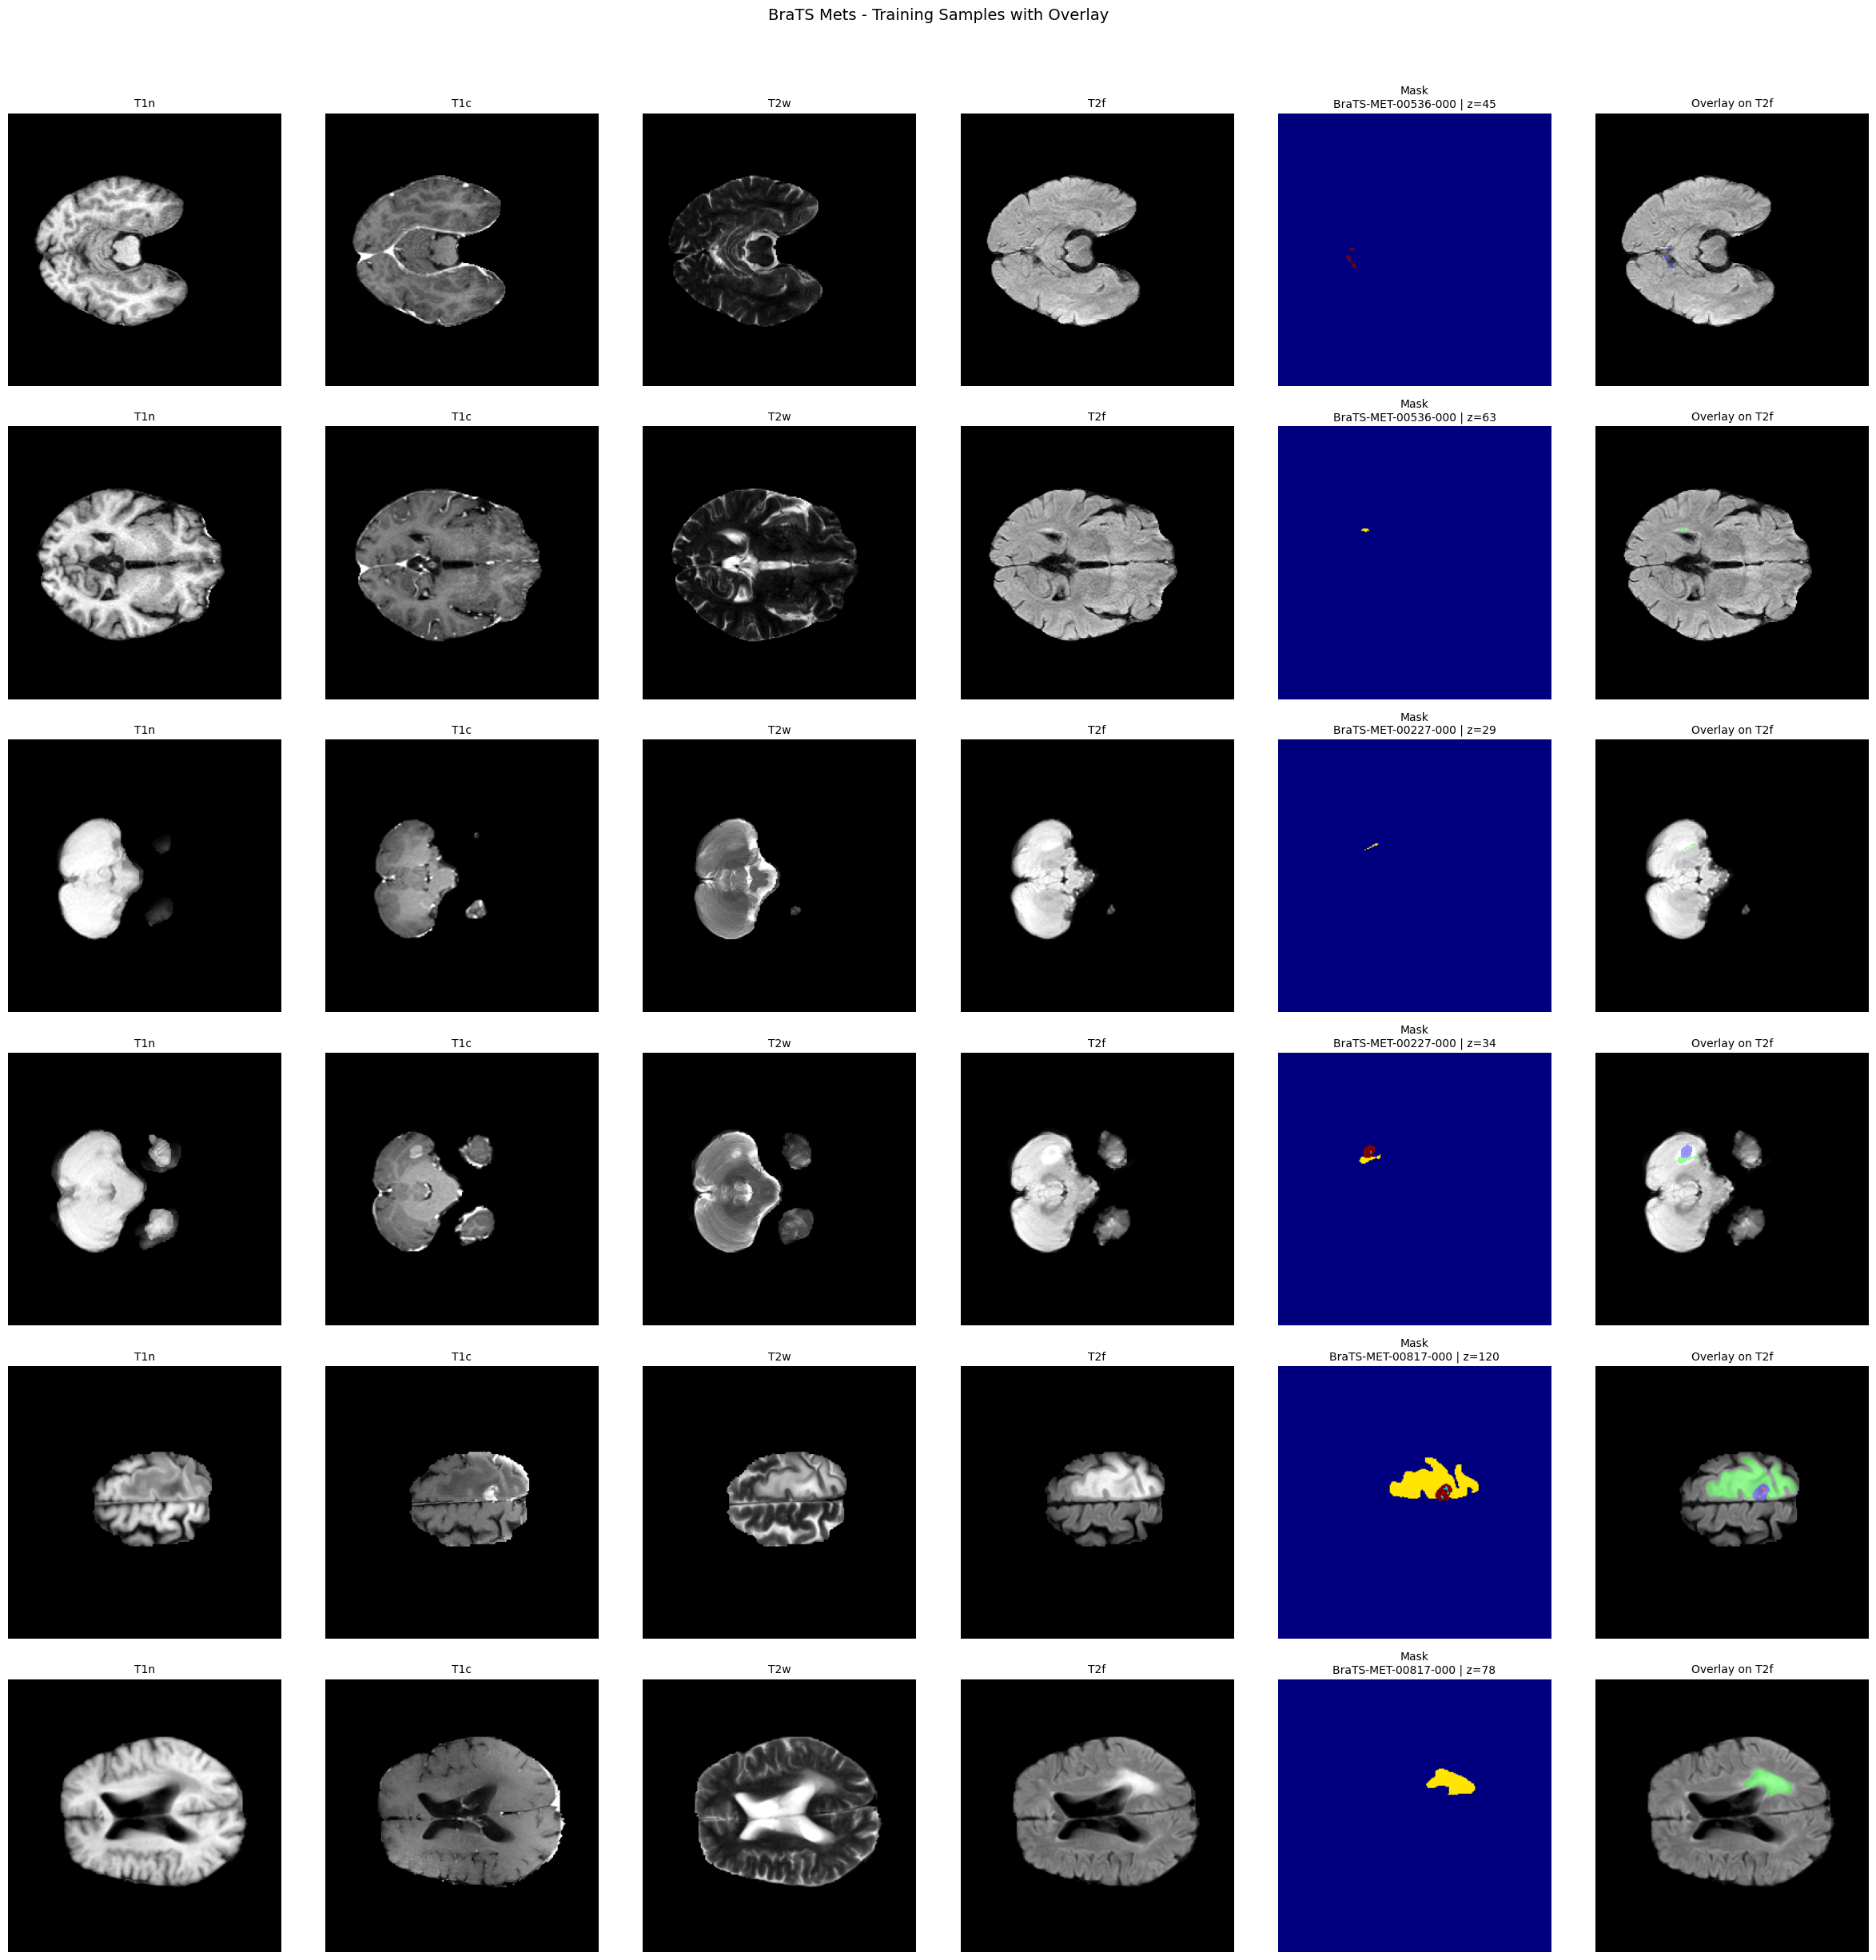

In [30]:
# Cell 32 — Use training dataset only

plot_sample_slices_with_overlay_mets(
    train_df,
    num_cases=3,
    slices_per_case=2,
    title="BraTS Mets - Training Samples with Overlay"
)

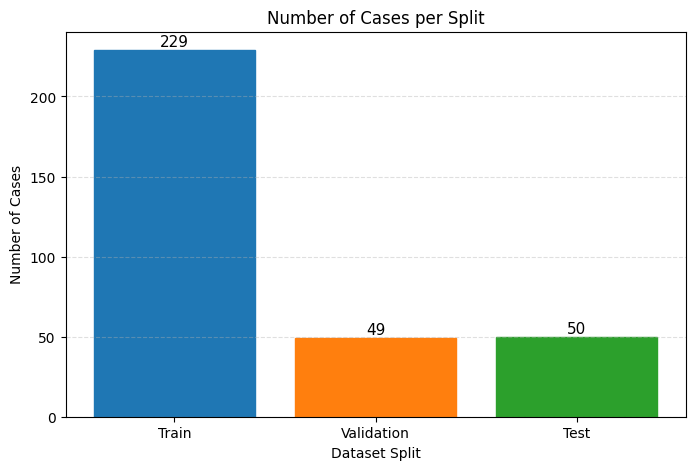

In [31]:
# Cell 33 — Histogram for number of cases in train / val / test

def plot_case_count_histogram(train_df, val_df, test_df, title="Number of Cases per Split"):
    split_names = ["Train", "Validation", "Test"]
    counts = [len(train_df), len(val_df), len(test_df)]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(split_names, counts)

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for bar, color in zip(bars, colors):
        bar.set_color(color)

    for i, count in enumerate(counts):
        plt.text(i, count + max(counts) * 0.01, str(count), ha="center", fontsize=11)

    plt.title(title)
    plt.ylabel("Number of Cases")
    plt.xlabel("Dataset Split")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()


plot_case_count_histogram(train_df, val_df, test_df)

In [32]:
# Cell 34 — Count exact filtered slices in train / val / test

def count_filtered_slices_in_split(cases_df, split_name="Split", min_brain_pixels=50):
    """
    Counts exact number of filtered slices in a split using the same preprocessing rules.
    """
    total_slices = 0
    tumor_slices = 0

    for i in range(len(cases_df)):
        row = cases_df.iloc[i]

        try:
            case_data = load_brats_mets_case(row)

            _, Y_list, meta = extract_filtered_slices_from_case(
                case_data,
                drop_empty_brain_slices=True,
                drop_non_tumor_slices=False,
                min_brain_pixels=min_brain_pixels
            )

            total_slices += len(Y_list)
            tumor_slices += sum(m["has_tumor"] for m in meta)

            del case_data, Y_list, meta
            gc.collect()

        except Exception as e:
            print(f"⚠ Skipping {row['case_id']} in {split_name}: {e}")

    return total_slices, tumor_slices


train_slice_count, train_tumor_slice_count = count_filtered_slices_in_split(train_df, split_name="Train")
val_slice_count, val_tumor_slice_count     = count_filtered_slices_in_split(val_df, split_name="Validation")
test_slice_count, test_tumor_slice_count   = count_filtered_slices_in_split(test_df, split_name="Test")

print("Exact filtered slice counts:")
print(f"Train: total={train_slice_count}, tumor={train_tumor_slice_count}")
print(f"Val:   total={val_slice_count}, tumor={val_tumor_slice_count}")
print(f"Test:  total={test_slice_count}, tumor={test_tumor_slice_count}")

Exact filtered slice counts:
Train: total=31747, tumor=12770
Val:   total=6802, tumor=2678
Test:  total=6936, tumor=2691


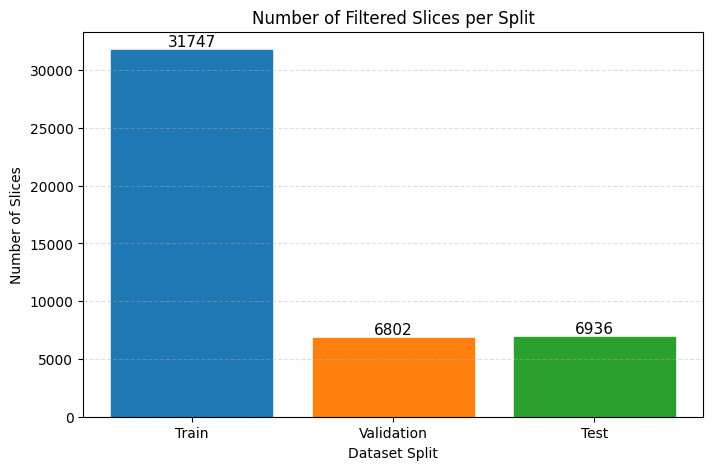

In [33]:
# Cell 35 — Histogram for number of slices in train / val / test

def plot_slice_count_histogram(
    train_slice_count,
    val_slice_count,
    test_slice_count,
    title="Number of Filtered Slices per Split"
):
    split_names = ["Train", "Validation", "Test"]
    counts = [train_slice_count, val_slice_count, test_slice_count]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(split_names, counts)

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for bar, color in zip(bars, colors):
        bar.set_color(color)

    for i, count in enumerate(counts):
        plt.text(i, count + max(counts) * 0.01, str(count), ha="center", fontsize=11)

    plt.title(title)
    plt.ylabel("Number of Slices")
    plt.xlabel("Dataset Split")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()


plot_slice_count_histogram(
    train_slice_count,
    val_slice_count,
    test_slice_count
)

In [34]:
# Cell 36 — Compute exact pixel counts per label from training set only

def compute_training_pixel_counts(train_df, num_classes=4, verbose=True):
    """
    Compute exact pixel counts for each segmentation label
    using ONLY the training split.

    Parameters
    ----------
    train_df : pd.DataFrame
        DataFrame containing training cases only.

    num_classes : int
        Number of segmentation classes. For BraTS Mets: 4 labels {0,1,2,3}.

    verbose : bool
        If True, prints progress.

    Returns
    -------
    pixel_counts : dict
        Dictionary mapping label -> exact pixel count across the training set.
    """
    pixel_counts = {c: 0 for c in range(num_classes)}

    for i in range(len(train_df)):
        row = train_df.iloc[i]
        case_id = row["case_id"]

        try:
            seg_raw = np.asanyarray(nib.load(row["seg_path"]).dataobj).astype(np.uint8)
            seg_mc = prepare_seg_mask(seg_raw)

            labels, counts = np.unique(seg_mc, return_counts=True)

            for label, count in zip(labels.tolist(), counts.tolist()):
                if label in pixel_counts:
                    pixel_counts[label] += int(count)

            if verbose and ((i + 1) % 10 == 0 or (i + 1) == len(train_df)):
                print(f"[{i+1}/{len(train_df)}] Processed case: {case_id}")

        except Exception as e:
            print(f"⚠ Skipping {case_id}: {e}")

    return pixel_counts

In [35]:
# Cell 37 — Run counting

train_pixel_counts = compute_training_pixel_counts(train_df, num_classes=4, verbose=True)

print("\nExact pixel counts in TRAINING set only:")
for label, count in train_pixel_counts.items():
    print(f"Label {label}: {count:,}")

[10/229] Processed case: BraTS-MET-00817-000
[20/229] Processed case: BraTS-MET-00821-000
[30/229] Processed case: BraTS-MET-00100-000
[40/229] Processed case: BraTS-MET-00304-000
[50/229] Processed case: BraTS-MET-00028-000
[60/229] Processed case: BraTS-MET-00275-000
[70/229] Processed case: BraTS-MET-00219-000
[80/229] Processed case: BraTS-MET-00789-000
[90/229] Processed case: BraTS-MET-00022-000
[100/229] Processed case: BraTS-MET-00027-000
[110/229] Processed case: BraTS-MET-00113-000
[120/229] Processed case: BraTS-MET-00796-000
[130/229] Processed case: BraTS-MET-00089-000
[140/229] Processed case: BraTS-MET-00202-000
[150/229] Processed case: BraTS-MET-00790-000
[160/229] Processed case: BraTS-MET-00009-000
[170/229] Processed case: BraTS-MET-00538-000
[180/229] Processed case: BraTS-MET-00262-000
[190/229] Processed case: BraTS-MET-00208-000
[200/229] Processed case: BraTS-MET-00196-000
[210/229] Processed case: BraTS-MET-00231-000
[220/229] Processed case: BraTS-MET-00192-0

In [27]:
# Cell 38 — Imports

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50

In [28]:
# Cell 39 — Shared conv block

def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x

In [29]:
# Cell 40 — Shared transformer bottleneck

def transformer_bottleneck(x, num_heads=4, key_dim=64, ff_dim=256, dropout=0.1):
    """
    Simple transformer bottleneck over the spatial tokens.
    Input shape: (B, H, W, C)
    Output shape: (B, H, W, C)
    """
    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]

    x1 = layers.Reshape((h * w, c))(x)

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x1, x1)

    x2 = layers.Add()([x1, attn])
    x2 = layers.LayerNormalization()(x2)

    ff = layers.Dense(ff_dim, activation="relu")(x2)
    ff = layers.Dense(c)(ff)

    x3 = layers.Add()([x2, ff])
    x3 = layers.LayerNormalization()(x3)

    out = layers.Reshape((h, w, c))(x3)
    return out

In [30]:
# Cell 41 — Attention blocks

def attention_gate(skip, gating, inter_filters):
    theta_x = layers.Conv2D(inter_filters, 1, padding="same")(skip)
    phi_g   = layers.Conv2D(inter_filters, 1, padding="same")(gating)

    add = layers.Add()([theta_x, phi_g])
    add = layers.Activation("relu")(add)

    psi = layers.Conv2D(1, 1, padding="same")(add)
    psi = layers.Activation("sigmoid")(psi)

    out = layers.Multiply()([skip, psi])
    return out


def attention_decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(x)
    skip = attention_gate(skip, x, inter_filters=max(filters // 2, 1))
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x

# Residual U-Net

In [29]:
# Cell 38 — Mets-compatible 2D U-Net model

from tensorflow.keras import layers, Model


def conv_bn_relu(x, filters, kernel_size=3):
    x = layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


def residual_block(x, filters, dropout_rate=0.0):
    """
    Residual conv block:
    input -> ConvBNReLU -> ConvBN -> add shortcut -> ReLU
    """
    shortcut = x

    # project shortcut if needed
    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", kernel_initializer="he_normal")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    y = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)

    y = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(y)
    y = layers.BatchNormalization()(y)

    y = layers.Add()([shortcut, y])
    y = layers.Activation("relu")(y)

    if dropout_rate > 0:
        y = layers.Dropout(dropout_rate)(y)

    return y


def attention_gate(skip, gating, inter_filters):
    """
    Simple attention gate for skip connection refinement.
    Helps suppress irrelevant background features.
    """
    theta_x = layers.Conv2D(inter_filters, 1, padding="same")(skip)
    phi_g   = layers.Conv2D(inter_filters, 1, padding="same")(gating)

    add = layers.Add()([theta_x, phi_g])
    add = layers.Activation("relu")(add)

    psi = layers.Conv2D(1, 1, padding="same")(add)
    psi = layers.Activation("sigmoid")(psi)

    out = layers.Multiply()([skip, psi])
    return out


def encoder_block(x, filters, dropout_rate=0.0):
    skip = residual_block(x, filters, dropout_rate=dropout_rate)
    pool = layers.MaxPooling2D((2, 2))(skip)
    return skip, pool


def decoder_block(x, skip, filters, dropout_rate=0.0, use_attention=True):
    x = layers.Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding="same")(x)

    if use_attention:
        skip = attention_gate(skip, x, inter_filters=max(filters // 2, 1))

    x = layers.Concatenate()([x, skip])
    x = residual_block(x, filters, dropout_rate=dropout_rate)
    return x


def build_mets_unet(
    input_shape=(240, 240, 4),
    num_classes=4,
    filters=(32, 64, 128, 256),
    bottleneck_filters=512,
    dropout_encoder=0.05,
    dropout_bottleneck=0.20,
    dropout_decoder=0.05,
    use_attention=True
):
    """
    BraTS Mets-compatible 2D U-Net:
    - lighter than the original 64-128-256-512-1024 U-Net
    - residual blocks for better optimization
    - attention-gated skip connections for small lesion focus

    Output:
        (240, 240, num_classes) with softmax
    """
    inputs = layers.Input(shape=input_shape)

    # Encoder
    skips = []
    x = inputs

    for f in filters:
        skip, x = encoder_block(x, f, dropout_rate=dropout_encoder)
        skips.append(skip)

    # Bottleneck
    x = residual_block(x, bottleneck_filters, dropout_rate=dropout_bottleneck)

    # Decoder
    for i, f in enumerate(reversed(filters)):
        skip = skips[-(i + 1)]
        x = decoder_block(
            x,
            skip,
            f,
            dropout_rate=dropout_decoder,
            use_attention=use_attention
        )

    # Output
    outputs = layers.Conv2D(
        num_classes,
        (1, 1),
        activation="softmax",
        dtype="float32"
    )(x)

    model = Model(inputs, outputs, name="UNet_BraTS_Mets_2D")
    return model


print("BraTS Mets model architecture defined.")

BraTS Mets model architecture defined.


In [32]:
# Cell 39 — Build and compile the mets model

model = build_mets_unet(
    input_shape=(240, 240, 4),
    num_classes=NUM_CLASSES,
    filters=(32, 64, 128, 256),
    bottleneck_filters=512,
    dropout_encoder=0.05,
    dropout_bottleneck=0.20,
    dropout_decoder=0.05,
    use_attention=True
)

LEARNING_RATE = 1e-4

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
)

model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Approx model size: {total_params * 4 / 1024**2:.1f} MB (float32)")

Model: "UNet_BraTS_Mets_2D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │        160 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 240, 240,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 240,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 240, 240,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 240, 240,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 240, 240,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 120, 120,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 120, 120,  │     36,928 │ activation_2[0][

 Total params: 8,215,672 (31.34 MB)

 Trainable params: 8,206,840 (31.31 MB)

 Non-trainable params: 8,832 (34.50 KB)


Total parameters: 8,215,672
Approx model size: 31.3 MB (float32)


In [33]:
# Cell 40 — Training callbacks

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

CHECKPOINT_PATH = "/kaggle/working/unet_brats_mets_best.keras"
LOG_PATH        = "/kaggle/working/training_log_mets.csv"

callbacks = [
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(LOG_PATH, separator=",", append=False),
]

EPOCHS = 50


print("Callbacks configured:")
print(f"  Checkpoint: {CHECKPOINT_PATH}")
print(f"  CSV log:    {LOG_PATH}")
print("  EarlyStopping patience: 8")
print("  ReduceLR patience: 3, factor: 0.5")

Callbacks configured:
  Checkpoint: /kaggle/working/unet_brats_mets_best.keras
  CSV log:    /kaggle/working/training_log_mets.csv
  EarlyStopping patience: 8
  ReduceLR patience: 3, factor: 0.5


In [35]:
# Cell 41 — Training

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1779373854.649251     131 service.cc:152] XLA service 0x7cae54004620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779373854.649293     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779373858.243147     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


      1/Unknown 89s 89s/step - dice_coef: 8.7607e-04 - dice_ed: 0.0026 - dice_et: 6.9960e-11 - dice_ncr: 8.8374e-11 - loss: 1.2448

I0000 00:00:1779373888.828811     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   3969/Unknown 895s 203ms/step - dice_coef: 0.0597 - dice_ed: 0.1163 - dice_et: 0.0443 - dice_ncr: 0.0184 - loss: 0.4930

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_dice_coef improved from -inf to 0.11496, saving model to /kaggle/working/unet_brats_mets_best.keras
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 1070s 247ms/step - dice_coef: 0.0597 - dice_ed: 0.1163 - dice_et: 0.0443 - dice_ncr: 0.0185 - loss: 0.4930 - val_dice_coef: 0.1150 - val_dice_ed: 0.2045 - val_dice_et: 0.1087 - val_dice_ncr: 0.0316 - val_loss: 0.4507 - learning_rate: 1.0000e-04
Epoch 2/50
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - dice_coef: 0.1370 - dice_ed: 0.2212 - dice_et: 0.1344 - dice_ncr: 0.0554 - loss: 0.3567
Epoch 2: val_dice_coef improved from 0.11496 to 0.13449, saving model to /kaggle/working/unet_brats_mets_best.keras
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 836s 204ms/step - dice_coef: 0.1370 - dice_ed: 0.2212 - dice_et: 0.1344 - dice_ncr: 0.0554 - loss: 0.3567 - val_dice_coef: 0.1345 - val_dice_ed: 0.2302 - val_dice_et: 0.1309 - val_dice_ncr: 0.0423 - val_loss: 0.4364 - learning_rate: 1.0000e-04
Epoch 3/50
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - dice_coef: 0.15

KeyboardInterrupt: 

In [40]:
import os
import json
import shutil
from pathlib import Path

# --- (A) Model files ---
MODEL_FILE_1 = Path("/kaggle/working/unet_brats_mets_best.keras")
MODEL_FILE_2 = Path("/kaggle/working/residual_unet_brats_mets_best_v1_20.keras")

# If second file is not saved yet, save it now:
model.save("/kaggle/working/residual_unet_brats_mets_best_v1_20.keras")

# --- (B) Dataset slug ---
DATASET_SLUG = "residual-unet-mets-best-v1-model"

# --- (C) Kaggle credentials ---
os.environ["KAGGLE_USERNAME"] = "moamengaber"
os.environ["KAGGLE_KEY"] = "KGAT_bd5aed250519d25d106c6a3a74c1524c"   # put your Kaggle API key here

# --- (D) Prepare upload folder ---
UPLOAD_DIR = Path("/kaggle/working/kaggle_model_upload")
if UPLOAD_DIR.exists():
    shutil.rmtree(UPLOAD_DIR)
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# --- (E) Copy files ---
for model_file in [MODEL_FILE_1, MODEL_FILE_2]:
    if model_file.exists():
        shutil.copy2(model_file, UPLOAD_DIR / model_file.name)
        print(f"Copied: {model_file.name}")
    else:
        print(f"Warning: file not found -> {model_file}")

# --- (F) Create metadata ---
meta = {
    "title": "Res-UNet BRATS Mets Best Model",
    "id": f"{os.environ['KAGGLE_USERNAME']}/{DATASET_SLUG}",
    "licenses": [{"name": "CC0-1.0"}],
    "isPrivate": True
}

with open(UPLOAD_DIR / "dataset-metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\nFiles prepared for upload:")
for p in UPLOAD_DIR.iterdir():
    print("-", p.name)

# --- (G) Create dataset ---
!pip -q install kaggle
!kaggle datasets create -p "{UPLOAD_DIR}" -u

Copied: unet_brats_mets_best.keras
Copied: residual_unet_brats_mets_best_v1_20.keras

Files prepared for upload:
- unet_brats_mets_best.keras
- dataset-metadata.json
- residual_unet_brats_mets_best_v1_20.keras
Dataset creation error: The requested title "Res-UNet BRATS Mets Best Model" is already in use by a dataset. Please choose another title.


In [ ]:
# model = build_mets_unet(
#     input_shape=(240, 240, 4),
#     num_classes=NUM_CLASSES,
#     filters=(16, 32, 64, 128),
#     bottleneck_filters=256,
#     dropout_encoder=0.05,
#     dropout_bottleneck=0.20,
#     dropout_decoder=0.05,
#     use_attention=True
# )

In [41]:
import os
import json
import shutil
from pathlib import Path

# --- (A) Model files ---
MODEL_FILE_1 = Path("/kaggle/working/unet_brats_mets_best.keras")
MODEL_FILE_2 = Path("/kaggle/working/residual_unet_brats_mets_best_v1_20.keras")

# If second file is not saved yet, save it now
model.save(str(MODEL_FILE_2))

# --- (B) Dataset info ---
KAGGLE_USERNAME = "moamengaber"
DATASET_SLUG = "residual-unet-mets-best-v1-model"
DATASET_TITLE = "Res-UNet BRATS Mets Best Model"   # can keep same for existing dataset

# --- (C) Kaggle credentials ---
# Prefer kaggle.json or Kaggle secrets in practice
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = "KGAT_bd5aed250519d25d106c6a3a74c1524c"   # replace in your notebook only

# --- (D) Prepare upload folder ---
UPLOAD_DIR = Path("/kaggle/working/kaggle_model_upload")
if UPLOAD_DIR.exists():
    shutil.rmtree(UPLOAD_DIR)
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# --- (E) Copy files ---
for model_file in [MODEL_FILE_1, MODEL_FILE_2]:
    if model_file.exists():
        shutil.copy2(model_file, UPLOAD_DIR / model_file.name)
        print(f"Copied: {model_file.name}")
    else:
        print(f"Warning: file not found -> {model_file}")

# --- (F) Create metadata ---
meta = {
    "title": DATASET_TITLE,
    "id": f"{KAGGLE_USERNAME}/{DATASET_SLUG}",
    "licenses": [{"name": "CC0-1.0"}],
    "isPrivate": True
}

with open(UPLOAD_DIR / "dataset-metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\nFiles prepared for upload:")
for p in UPLOAD_DIR.iterdir():
    print("-", p.name)

# --- (G) Install / upgrade kaggle CLI ---
!pip -q install --upgrade kaggle

# --- (H) Check whether dataset already exists ---
import subprocess

dataset_ref = f"{KAGGLE_USERNAME}/{DATASET_SLUG}"

check_cmd = f'kaggle datasets status {dataset_ref}'
check_result = subprocess.run(check_cmd, shell=True, capture_output=True, text=True)

# --- (I) Create or version ---
if check_result.returncode == 0:
    print(f"\nDataset already exists: {dataset_ref}")
    print("Uploading a new VERSION instead of creating a new dataset...\n")
    !kaggle datasets version -p "{UPLOAD_DIR}" -m "Updated model files"
else:
    print(f"\nDataset does not exist yet: {dataset_ref}")
    print("Creating new dataset...\n")
    !kaggle datasets create -p "{UPLOAD_DIR}" -u

Copied: unet_brats_mets_best.keras
Copied: residual_unet_brats_mets_best_v1_20.keras

Files prepared for upload:
- unet_brats_mets_best.keras
- dataset-metadata.json
- residual_unet_brats_mets_best_v1_20.keras
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 19.4 MB/s eta 0:00:00

Dataset already exists: moamengaber/residual-unet-mets-best-v1-model
Uploading a new VERSION instead of creating a new dataset...

Starting upload for file unet_brats_mets_best.keras
100%|██████████████████████████████████████| 94.5M/94.5M [00:06<00:00, 14.8MB/s]
Upload successful: unet_brats_mets_best.keras (94MB)
Starting upload for file residual_unet_brats_mets_best_v1_20.keras
Error while trying to load upload info: KaggleObject.from_dict() got an unexpected keyword argument 'token'
100%|██████████████████████████████████████| 94.5M/94.5M [00:06<00:00, 15.5MB/s]
Upload successful: residual_unet_brats_mets_best_v1_20.

In [35]:
# Cell — Resume training (FIXED)

SAVED_MODEL_PATH = "/kaggle/input/datasets/moamengaber/residual-unet-mets-best-v1-model/residual_unet_brats_mets_best_v1_20.keras"
RESUME_FROM_EPOCH = 19
EPOCHS = 50
LEARNING_RATE = 5e-5

# Load model
model = tf.keras.models.load_model(
    SAVED_MODEL_PATH,
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coef": dice_coef,
        "dice_ncr": dice_ncr,
        "dice_ed": dice_ed,
        "dice_et": dice_et,
    }
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
)

# Callbacks
CHECKPOINT_PATH = "/kaggle/working/unet_brats_best.keras"
LOG_PATH = "/kaggle/working/training_log_resumed.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(LOG_PATH, separator=",", append=False),
]

# ┌──────────────────────────────────────────────────────┐
# │  KEY CHANGE: no steps_per_epoch, no validation_steps │
# │  TF will auto-detect when generator is exhausted     │
# │  Each epoch = exactly one full pass through data     │
# └──────────────────────────────────────────────────────┘

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=RESUME_FROM_EPOCH,
    callbacks=callbacks,
    verbose=1
)

Epoch 20/50


I0000 00:00:1779446563.518782     135 service.cc:152] XLA service 0x7ade28003260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779446563.518840     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779446568.690065     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


      1/Unknown 100s 100s/step - dice_coef: 0.9398 - dice_ed: 0.9568 - dice_et: 0.9270 - dice_ncr: 0.9356 - loss: 0.0429

I0000 00:00:1779446604.337161     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   3969/Unknown 923s 207ms/step - dice_coef: 0.8604 - dice_ed: 0.7876 - dice_et: 0.8570 - dice_ncr: 0.9367 - loss: 0.0867

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 20: val_dice_coef improved from -inf to 0.83748, saving model to /kaggle/working/unet_brats_best.keras
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 1120s 257ms/step - dice_coef: 0.8604 - dice_ed: 0.7876 - dice_et: 0.8570 - dice_ncr: 0.9367 - loss: 0.0867 - val_dice_coef: 0.8375 - val_dice_ed: 0.7679 - val_dice_et: 0.8410 - val_dice_ncr: 0.9035 - val_loss: 0.3077 - learning_rate: 5.0000e-05
Epoch 21/50
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - dice_coef: 0.8752 - dice_ed: 0.8130 - dice_et: 0.8753 - dice_ncr: 0.9372 - loss: 0.0848
Epoch 21: val_dice_coef improved from 0.83748 to 0.85063, saving model to /kaggle/working/unet_brats_best.keras
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 910s 223ms/step - dice_coef: 0.8752 - dice_ed: 0.8130 - dice_et: 0.8753 - dice_ncr: 0.9372 - loss: 0.0848 - val_dice_coef: 0.8506 - val_dice_ed: 0.8143 - val_dice_et: 0.8392 - val_dice_ncr: 0.8983 - val_loss: 0.2753 - learning_rate: 5.0000e-05
Epoch 22/50
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - dice_coef: 0.8673 - d

KeyboardInterrupt: 

# Attention U-Net

In [31]:

def build_attention_unet(
    input_shape=(240, 240, 4),
    num_classes=4,
    dropout_rate=0.1
):
    inputs = layers.Input(shape=input_shape, name="input_mri")

    c1 = conv_block(inputs, 64, dropout_rate)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128, dropout_rate)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256, dropout_rate)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512, dropout_rate)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    bn = conv_block(p4, 1024, dropout_rate)

    x = attention_decoder_block(bn, c4, 512, dropout_rate)
    x = attention_decoder_block(x,  c3, 256, dropout_rate)
    x = attention_decoder_block(x,  c2, 128, dropout_rate)
    x = attention_decoder_block(x,  c1,  64, dropout_rate)

    outputs = layers.Conv2D(
        num_classes, 1, activation="softmax", dtype="float32", name="segmentation_head"
    )(x)

    return Model(inputs, outputs, name="Attention_UNet_BraTS")

In [32]:
model = build_attention_unet(
    input_shape=(240, 240, 4),
    num_classes=4,
)

LEARNING_RATE = 1e-4

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
)

model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Approx model size: {total_params * 4 / 1024**2:.1f} MB (float32)")

Model: "Attention_UNet_BraTS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_mri           │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │      2,368 │ input_mri[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 240,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 240, 240,  │          0 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 120, 120,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 120, 120,  │          0 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 60, 60,    │          0 │ dropout_1[0][0] 

 Total params: 31,926,952 (121.79 MB)

 Trainable params: 31,915,176 (121.75 MB)

 Non-trainable params: 11,776 (46.00 KB)


Total parameters: 31,926,952
Approx model size: 121.8 MB (float32)


In [33]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

CHECKPOINT_PATH = "/kaggle/working/unet_brats_mets_best.keras"
LOG_PATH        = "/kaggle/working/training_log_mets.csv"

callbacks = [
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(LOG_PATH, separator=",", append=False),
]

EPOCHS = 50


print("Callbacks configured:")
print(f"  Checkpoint: {CHECKPOINT_PATH}")
print(f"  CSV log:    {LOG_PATH}")
print("  EarlyStopping patience: 8")
print("  ReduceLR patience: 3, factor: 0.5")

Callbacks configured:
  Checkpoint: /kaggle/working/unet_brats_mets_best.keras
  CSV log:    /kaggle/working/training_log_mets.csv
  EarlyStopping patience: 8
  ReduceLR patience: 3, factor: 0.5


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1779527732.923202     130 service.cc:152] XLA service 0x78c1f0002960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779527732.923260     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779527735.602471     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779527774.304808     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   3968/Unknown 1135s 262ms/step - dice_coef: 0.0504 - dice_ed: 0.0967 - dice_et: 0.0428 - dice_ncr: 0.0116 - loss: 0.4935

2026-05-23 09:33:40.433548: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 09:33:40.678685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   3969/Unknown 1163s 269ms/step - dice_coef: 0.0504 - dice_ed: 0.0968 - dice_et: 0.0428 - dice_ncr: 0.0116 - loss: 0.4935

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-05-23 09:36:11.932045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 09:36:12.176621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_dice_coef improved from -inf to 0.11511, saving model to /kaggle/working/unet_brats_mets_best.keras
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 1298s 303ms/step - dice_coef: 0.0504 - dice_ed: 0.0968 - dice_et: 0.0429 - dice_ncr: 0.0116 - loss: 0.4935 - val_dice_coef: 0.1151 - val_dice_ed: 0.1998 - val_dice_et: 0.1083 - val_dice_ncr: 0.0372 - val_loss: 0.4041 - learning_rate: 1.0000e-04
Epoch 2/50
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - dice_coef: 0.1356 - dice_ed: 0.2181 - dice_et: 0.1335 - dice_ncr: 0.0552 - loss: 0.3568
Epoch 2: val_dice_coef improved from 0.11511 to 0.13277, saving model to /kaggle/working/unet_brats_mets_best.keras
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 1178s 291ms/step - dice_coef: 0.1356 - dice_ed: 0.2181 - dice_et: 0.1335 - dice_ncr: 0.0552 - loss: 0.3568 - val_dice_coef: 0.1328 - val_dice_ed: 0.2273 - val_dice_et: 0.1276 - val_dice_ncr: 0.0434 - val_loss: 0.4462 - learning_rate: 1.0000e-04
Epoch 3/50
3969/3969 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - dice_coef: 0.1